# SDSS Local Manager: Pipeline Demonstration

This notebook demonstrates how to use the `sdss_manager` library to automatically sync a subset of the Sloan Digital Sky Survey (SDSS) data, index its astronomical metadata into a local SQLite database, and query the catalog cleanly.

In [7]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.abspath(os.path.join("..")))
from sdss_manager.core import SDSSDatabase

# Jupyter-specific Pandas configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

## 1. Initialize and Update the Database
We instantiate the `SDSSDatabase` manager, pointing it to a local data directory and a metadata database file. Calling `update_database()` will trigger the differential Rsync sync and automatically index any newly arrived FITS files.

In [8]:
# Define paths
DATA_DIR = "../data/sdss_subset"
DB_PATH = "../sdss_metadata.db"

# Initialize the library wrapper
db = SDSSDatabase(local_base_dir=DATA_DIR, db_path=DB_PATH)

# Run the pipeline (Syncs missing files + extracts FITS headers into SQL)
db.update_database()

Connecting to SDSS Server and syncing files...
Source: rsync://dtn.sdss.org/dr19/spectro/boss/redux/v6_1_3/
This will run silently in the background until completion.


rsync(11540): error: read: Connection reset by peer
rsync(11540): error: io_read_nonblocking
rsync(11540): error: io_read_blocking
rsync(11540): error: io_read_flush
rsync(11540): error: io_read_buf
rsync(11540): error: flist_recv_name
rsync(11540): error: flist_recv
rsync(11540): error: rsync_receiver


**********************************************************************
NOTICE TO USERS
You have reached the SDSS data transfer node. Access to SDSS data
is provided without any guarantees whatsoever. In addition, access
is subject to these conditions:
 * No more than ten (10) connections are permitted.
 * No warnings will be given if the rsync server needs to be
   rebooted or otherwise taken offline.
 * Long-running or otherwise excessive rsync jobs are subject to
   termination without notice.
 * The SDSS data set comprises many terabytes, and rsync is
   designed for small data transfers.  If we think you are
   trying to download many terabytes with rsync, that qualifies
   as a long-running or otherwise excessive job.   If you
   need that much data, there are much better tools than rsync
   available. Contact the SDSS Help Desk at helpdesk@sdss.org
   for assistance.
That said, here are some hints for using the SDSS rsync server:
 * If you cannot connect to dtn.sdss.org, revert t

Parsing FITS Headers: 6310 files [18:29,  5.69 files/s] 


Database indexing finished!


## 2. Inspecting the Parsed Catalog
Instead of scanning gigabytes of FITS files every time, this library queries the indexed SQLite database instantly. Load this into a Pandas DataFrame for rich analysis.

In [9]:
# Fetch the indexed catalog as a dataframe
df = db.get_catalog()

print(f"Total observations indexed: {len(df)}")

# Style the output: format floats, handle missing values, and highlight key columns
styled_df = (
    df.head(10)
    .style.format(
        {"ra": "{:.4f}°", "dec": "{:.4f}°", "exposure_time": "{:.1f}s"}
    )
    .highlight_max(axis=0, subset=["exposure_time"], color="#e6f2ff")
    .set_caption("SDSS Metadata Catalog (First 10 Observations)")
)

# Display the styled table natively in Jupyter
styled_df

Total observations indexed: 6310


,id,file_path,ra,dec,exposure_time,target_mag
0,1,../data/sdss_subset/fieldlist-v6_1_3.fits,nan°,nan°,nans,None
1,2,../data/sdss_subset/015000/spCFrame-r1-00319323.fits,35.7097°,-5.0519°,900.1s,None
2,3,../data/sdss_subset/015000/spCFrame-b1-00319424.fits,35.7100°,-5.0511°,900.1s,None
3,4,../data/sdss_subset/015000/spFluxdistort-015000-59232-00323635.fits,35.7104°,-5.0501°,900.1s,None
4,5,../data/sdss_subset/015000/spCFrame-r1-00323635.fits,35.7107°,-5.0499°,900.1s,None
5,6,../data/sdss_subset/015000/spCFrame-r1-00319677.fits,35.7103°,-5.0481°,900.1s,None
6,7,../data/sdss_subset/015000/spCFrame-b1-00320499.fits,35.7110°,-5.0501°,900.1s,None
7,8,../data/sdss_subset/015000/spFluxdistort-015000-59192-00320502.fits,35.7110°,-5.0501°,900.1s,None
8,9,../data/sdss_subset/015000/spCFrame-r1-00318676.fits,35.7061°,-5.0491°,900.1s,None
9,10,../data/sdss_subset/015000/spfibermap-015000-59189.fits,nan°,nan°,nans,None


## 3. Data Verification & Visualizations
Plot the spatial distribution (Right Ascension vs. Declination) of our downloaded targets, mapping the color intensity to their exposure times. This confirms coordinate parsing logic is entirely accurate.

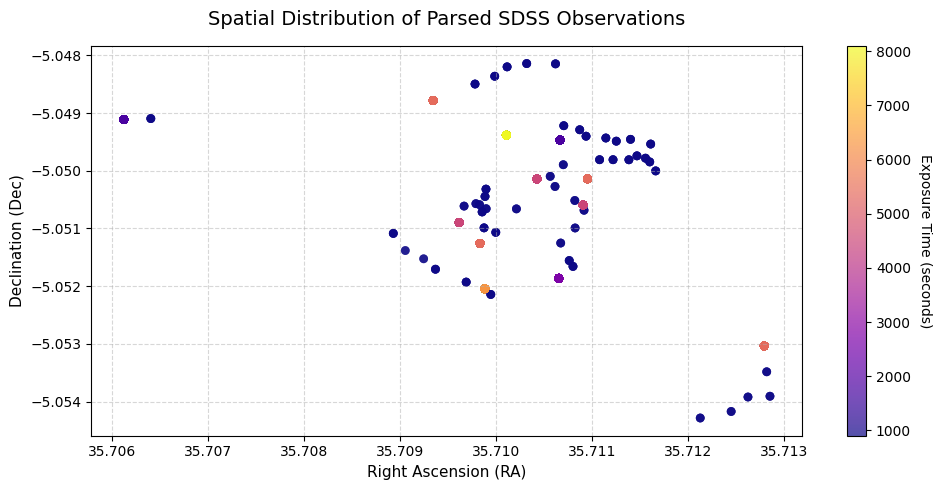

In [10]:
if not df.empty:
    plt.figure(figsize=(10, 5), dpi=100)

    # Create a scatter plot of the sky coordinates
    scatter = plt.scatter(
        df["ra"],
        df["dec"],
        c=df["exposure_time"],
        cmap="plasma",
        alpha=0.7,
        edgecolors="none",
        s=40,
    )

    # Initialize chart
    plt.title(
        "Spatial Distribution of Parsed SDSS Observations",
        fontsize=14,
        pad=15,
    )
    plt.xlabel("Right Ascension (RA)", fontsize=11)
    plt.ylabel("Declination (Dec)", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Colorbar to represent exposure depth
    cbar = plt.colorbar(scatter)
    cbar.set_label("Exposure Time (seconds)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot. Ensure files are properly indexed.")